# 05 Single-Cell Validation with Real Data (Scanpy) — Corrected Minimal 2 HC + 2 UC Version

This notebook is a corrected, memory-safer Scanpy workflow for the
`multiomics-perturbation-target-discovery` project.

## What changed

The GEO supplementary files for `GSE214695` are **raw droplet matrices**, not already-filtered
cell matrices. That means a direct `read_10x_mtx()` approach can inflate the number of apparent
cells dramatically.

This corrected notebook:

- loads the raw Matrix Market files manually
- assigns barcodes and feature names explicitly
- transposes the matrix correctly to cells × genes
- performs **early barcode filtering** before concatenation
- keeps only a **2 HC + 2 UC** subset for a workable first pass on a laptop

## Selected samples

- GSM6614348_HC-1
- GSM6614349_HC-2
- GSM6614354_UC-1
- GSM6614355_UC-2

## Downstream compatibility

The notebook exports exactly the files expected by your downstream workflow:

- `data/processed/single_cell/single_cell_target_expression.tsv`
- `data/processed/single_cell/single_cell_target_differential_expression.tsv`


## Expected inputs

Place the extracted GEO files under:

`data/raw/GSE214695/`

This notebook expects files like:

- `GSM6614348_HC-1_matrix.mtx.gz`
- `GSM6614348_HC-1_barcodes.tsv.gz`
- `GSM6614348_HC-1_features.tsv.gz`

and the same pattern for the other selected samples.


In [39]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import gzip
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

from scipy.io import mmread
from anndata import AnnData

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sc.settings.verbosity = 2
sc.set_figure_params(dpi=100, facecolor="white")


In [40]:
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "GSE214695"
PROCESSED_SC_DIR = PROJECT_ROOT / "data" / "processed" / "single_cell"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

PROCESSED_SC_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_FIGURES.mkdir(parents=True, exist_ok=True)

expr_out_file = PROCESSED_SC_DIR / "single_cell_target_expression.tsv"
de_out_file = PROCESSED_SC_DIR / "single_cell_target_differential_expression.tsv"

RAW_DIR, expr_out_file, de_out_file


(PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/raw/GSE214695'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/single_cell/single_cell_target_expression.tsv'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/single_cell/single_cell_target_differential_expression.tsv'))

In [41]:
TARGET_GENES = ["NR3C1", "FKBP5", "TSC22D3", "JAK1", "JAK2", "JAK3", "TYK2"]

SELECTED_PREFIXES = [
    "GSM6614348_HC-1",
    "GSM6614349_HC-2",
    "GSM6614354_UC-1",
    "GSM6614355_UC-2",
]

# Early raw-droplet filtering thresholds
MIN_COUNTS_PER_CELL = 500
MIN_GENES_PER_CELL_EARLY = 200

TARGET_GENES, SELECTED_PREFIXES


(['NR3C1', 'FKBP5', 'TSC22D3', 'JAK1', 'JAK2', 'JAK3', 'TYK2'],
 ['GSM6614348_HC-1', 'GSM6614349_HC-2', 'GSM6614354_UC-1', 'GSM6614355_UC-2'])

## Step 1 — Load and early-filter the raw droplet matrices


In [42]:
def parse_sample_prefixes(raw_dir: Path):
    matrix_files = sorted(raw_dir.glob("*_matrix.mtx.gz")) + sorted(raw_dir.glob("*_matrix.mtx"))
    prefixes = []
    for mf in matrix_files:
        prefix = re.sub(r"_matrix\.mtx(\.gz)?$", "", mf.name)
        prefixes.append(prefix)
    return sorted(prefixes)

def read_barcodes(barcode_path: Path):
    if str(barcode_path).endswith(".gz"):
        with gzip.open(barcode_path, "rt") as f:
            return pd.read_csv(f, header=None, sep="\t")[0].astype(str).tolist()
    return pd.read_csv(barcode_path, header=None, sep="\t")[0].astype(str).tolist()

def read_features(feature_path: Path):
    if str(feature_path).endswith(".gz"):
        with gzip.open(feature_path, "rt") as f:
            feat = pd.read_csv(f, header=None, sep="\t")
    else:
        feat = pd.read_csv(feature_path, header=None, sep="\t")

    if feat.shape[1] >= 2:
        gene_ids = feat.iloc[:, 0].astype(str).tolist()
        gene_symbols = feat.iloc[:, 1].astype(str).tolist()
    else:
        gene_ids = feat.iloc[:, 0].astype(str).tolist()
        gene_symbols = feat.iloc[:, 0].astype(str).tolist()

    return gene_ids, gene_symbols

def load_one_geo_sample_filtered(raw_dir: Path, prefix: str):
    matrix_src_gz = raw_dir / f"{prefix}_matrix.mtx.gz"
    matrix_src = raw_dir / f"{prefix}_matrix.mtx"
    barcode_src_gz = raw_dir / f"{prefix}_barcodes.tsv.gz"
    barcode_src = raw_dir / f"{prefix}_barcodes.tsv"
    features_src_gz = raw_dir / f"{prefix}_features.tsv.gz"
    features_src = raw_dir / f"{prefix}_features.tsv"
    genes_src_gz = raw_dir / f"{prefix}_genes.tsv.gz"
    genes_src = raw_dir / f"{prefix}_genes.tsv"

    matrix_file = matrix_src_gz if matrix_src_gz.exists() else matrix_src
    barcode_file = barcode_src_gz if barcode_src_gz.exists() else barcode_src

    if features_src_gz.exists():
        feature_file = features_src_gz
    elif features_src.exists():
        feature_file = features_src
    elif genes_src_gz.exists():
        feature_file = genes_src_gz
    else:
        feature_file = genes_src

    if not matrix_file.exists():
        raise FileNotFoundError(f"Missing matrix file for {prefix}")
    if not barcode_file.exists():
        raise FileNotFoundError(f"Missing barcode file for {prefix}")
    if not feature_file.exists():
        raise FileNotFoundError(f"Missing feature/gene file for {prefix}")

    print(f"Reading raw matrix for {prefix} ...")

    if str(matrix_file).endswith(".gz"):
        with gzip.open(matrix_file, "rb") as f:
            X = mmread(f).tocsr()
    else:
        X = mmread(str(matrix_file)).tocsr()

    gene_ids, gene_symbols = read_features(feature_file)
    barcodes = read_barcodes(barcode_file)

    # Matrix file is genes x barcodes, but AnnData expects cells x genes
    if X.shape[0] == len(gene_symbols) and X.shape[1] == len(barcodes):
        X = X.T.tocsr()
    elif X.shape[0] == len(barcodes) and X.shape[1] == len(gene_symbols):
        X = X.tocsr()
    else:
        raise ValueError(
            f"Unexpected matrix dimensions for {prefix}: {X.shape}, "
            f"{len(gene_symbols)} genes, {len(barcodes)} barcodes"
        )

    ad = AnnData(X=X)
    ad.obs_names = pd.Index(barcodes).astype(str)
    ad.var_names = pd.Index(gene_symbols).astype(str)
    ad.var_names_make_unique()
    ad.var["gene_id"] = gene_ids

    ad.obs["sample_id"] = prefix

    sample_upper = prefix.upper()
    if "_HC-" in sample_upper or sample_upper.endswith("_HC"):
        ad.obs["group"] = "HC"
    elif "_UC-" in sample_upper or sample_upper.endswith("_UC"):
        ad.obs["group"] = "UC"
    elif "_CD-" in sample_upper or sample_upper.endswith("_CD"):
        ad.obs["group"] = "CD"
    else:
        ad.obs["group"] = "unknown"

    # Early filtering before concatenation
    ad.obs["total_counts"] = np.asarray(ad.X.sum(axis=1)).ravel()
    ad.obs["n_genes_by_counts"] = np.asarray((ad.X > 0).sum(axis=1)).ravel()

    keep = (
        (ad.obs["total_counts"] >= MIN_COUNTS_PER_CELL) &
        (ad.obs["n_genes_by_counts"] >= MIN_GENES_PER_CELL_EARLY)
    )

    before = ad.n_obs
    ad = ad[keep].copy()
    after = ad.n_obs

    print(f"{prefix}: kept {after:,} / {before:,} barcodes after early filtering")

    return ad

def load_selected_geo_samples_filtered(raw_dir: Path, selected_prefixes):
    available_prefixes = set(parse_sample_prefixes(raw_dir))

    missing = [p for p in selected_prefixes if p not in available_prefixes]
    if missing:
        raise FileNotFoundError(
            "These selected sample prefixes were not found in the raw directory: "
            + ", ".join(missing)
        )

    print("Loading selected sample prefixes:")
    for p in selected_prefixes:
        print(" -", p)

    adatas = []
    for prefix in selected_prefixes:
        ad = load_one_geo_sample_filtered(raw_dir, prefix)
        adatas.append(ad)

    adata = sc.concat(
        adatas,
        join="outer",
        label="batch",
        keys=[ad.obs["sample_id"].iloc[0] for ad in adatas],
        index_unique="-"
    )

    return adata

adata = load_selected_geo_samples_filtered(RAW_DIR, SELECTED_PREFIXES)
print(adata)
print(adata.obs["group"].value_counts())
print(adata.obs["sample_id"].value_counts())
adata


Loading selected sample prefixes:
 - GSM6614348_HC-1
 - GSM6614349_HC-2
 - GSM6614354_UC-1
 - GSM6614355_UC-2
Reading raw matrix for GSM6614348_HC-1 ...
GSM6614348_HC-1: kept 1,681 / 737,280 barcodes after early filtering
Reading raw matrix for GSM6614349_HC-2 ...
GSM6614349_HC-2: kept 3,561 / 6,794,880 barcodes after early filtering
Reading raw matrix for GSM6614354_UC-1 ...
GSM6614354_UC-1: kept 1,482 / 6,794,880 barcodes after early filtering
Reading raw matrix for GSM6614355_UC-2 ...
GSM6614355_UC-2: kept 2,941 / 6,794,880 barcodes after early filtering
AnnData object with n_obs × n_vars = 9665 × 33538
    obs: 'sample_id', 'group', 'total_counts', 'n_genes_by_counts', 'batch'
group
HC    5242
UC    4423
Name: count, dtype: int64
sample_id
GSM6614349_HC-2    3561
GSM6614355_UC-2    2941
GSM6614348_HC-1    1681
GSM6614354_UC-1    1482
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 9665 × 33538
    obs: 'sample_id', 'group', 'total_counts', 'n_genes_by_counts', 'batch'

## Step 2 — QC metrics


In [43]:
adata.var_names = pd.Index(adata.var_names.astype(str)).str.strip()
adata.var_names_make_unique()

adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe()


,total_counts,n_genes_by_counts,pct_counts_mt
count,9665.000000,9665.000000,9665.000000
mean,10489.421314,1224.736368,13.336932
std,12133.832810,763.373398,19.288536
min,501.000000,200.000000,0.000000
25%,2107.000000,709.000000,2.224326
50%,4480.000000,1094.000000,4.893294
75%,17144.000000,1541.000000,13.900000
max,275567.000000,10982.000000,97.582114


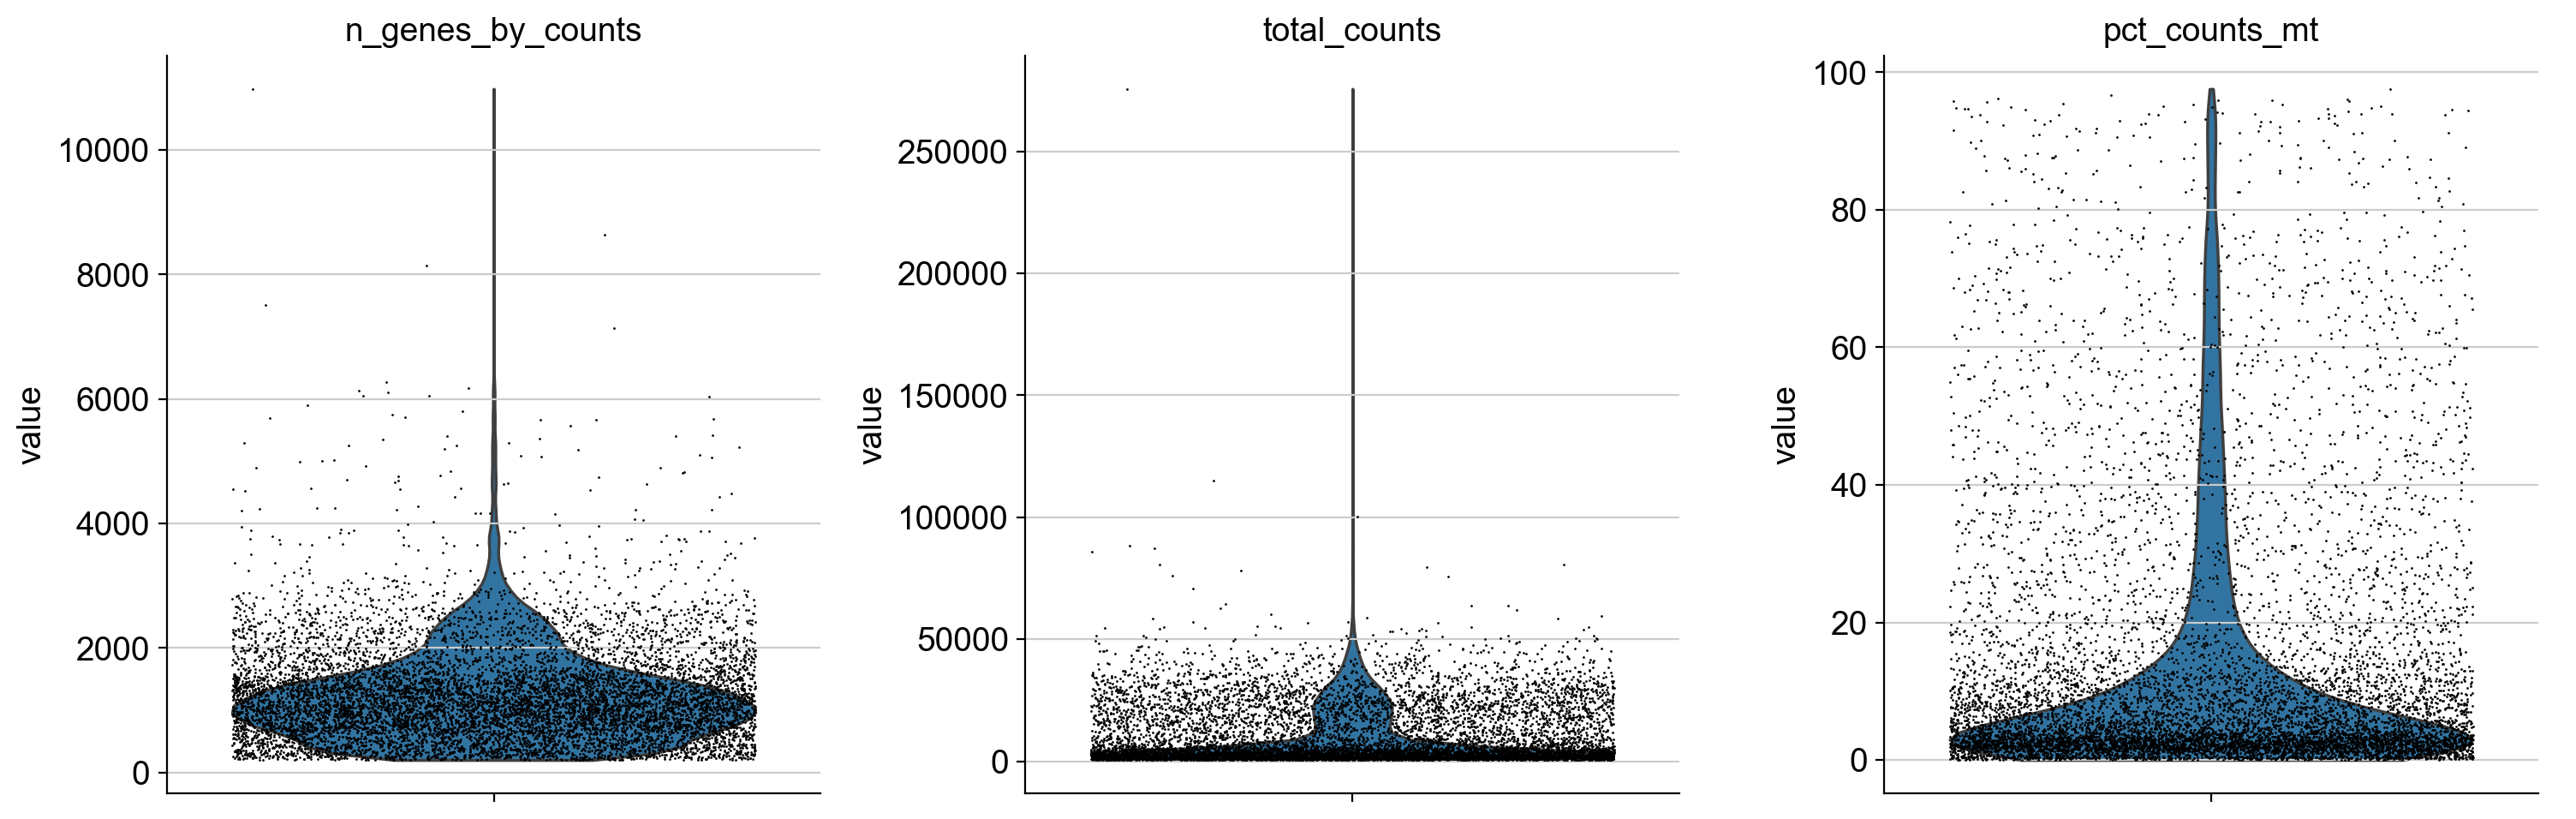

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/sc_real_qc_violin.png


In [44]:
fig = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    show=False
)
plt.tight_layout()
out = RESULTS_FIGURES / "sc_real_qc_violin.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)


## Step 3 — Additional filtering and save checkpoint


In [45]:
MIN_GENES_PER_CELL = 200
MIN_CELLS_PER_GENE = 3
MAX_MT_PCT = 20.0

adata = adata[adata.obs["n_genes_by_counts"] >= MIN_GENES_PER_CELL].copy()
adata = adata[adata.obs["pct_counts_mt"] < MAX_MT_PCT].copy()
sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)

print(adata)

checkpoint_out = PROCESSED_SC_DIR / "GSE214695_2HC_2UC_prefiltered_corrected.h5ad"
adata.write(checkpoint_out)
print("Saved:", checkpoint_out)


filtered out 13626 genes that are detected in less than 3 cells
AnnData object with n_obs × n_vars = 7785 × 19912
    obs: 'sample_id', 'group', 'total_counts', 'n_genes_by_counts', 'batch', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/single_cell/GSE214695_2HC_2UC_prefiltered_corrected.h5ad


## Step 4 — Normalize, log-transform, HVGs, PCA, neighbors, UMAP, Leiden


In [46]:
adata.layers["counts"] = adata.X.copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="seurat")
adata = adata[:, adata.var["highly_variable"]].copy()

sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="leiden")

adata


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:00)
computing UMAP
    finished (0:00:08)
running Leiden clustering
    finished (0:00:00)


AnnData object with n_obs × n_vars = 7785 × 3000
    obs: 'sample_id', 'group', 'total_counts', 'n_genes_by_counts', 'batch', 'total_counts_mt', 'pct_counts_mt', 'leiden'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

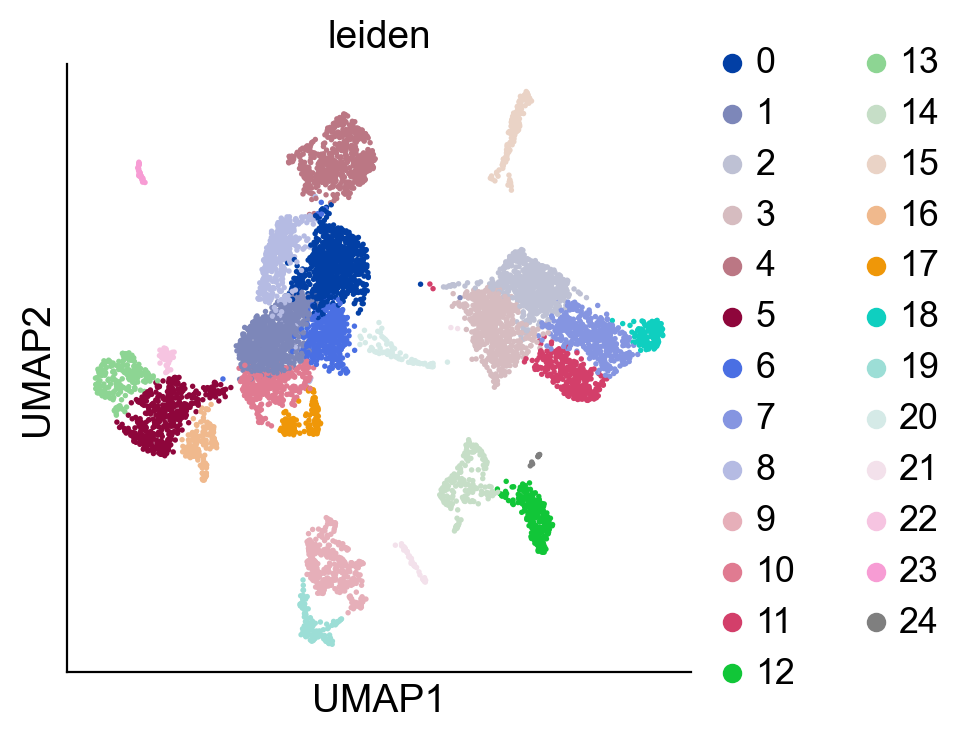

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/sc_real_umap_clusters.png


In [47]:
sc.pl.umap(adata, color=["leiden"], show=False)
out = RESULTS_FIGURES / "sc_real_umap_clusters.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)


## Step 5 — Broad marker inspection for manual annotation


Present marker genes: ['EPCAM', 'KRT8', 'KRT18', 'KRT19', 'CD3D', 'CD3E', 'TRBC1', 'IL7R', 'MS4A1', 'CD79A', 'MZB1', 'JCHAIN', 'LYZ', 'S100A8', 'S100A9', 'CTSS', 'FCN1', 'PECAM1', 'VWF', 'KDR', 'COL1A1', 'COL1A2', 'DCN', 'LUM']


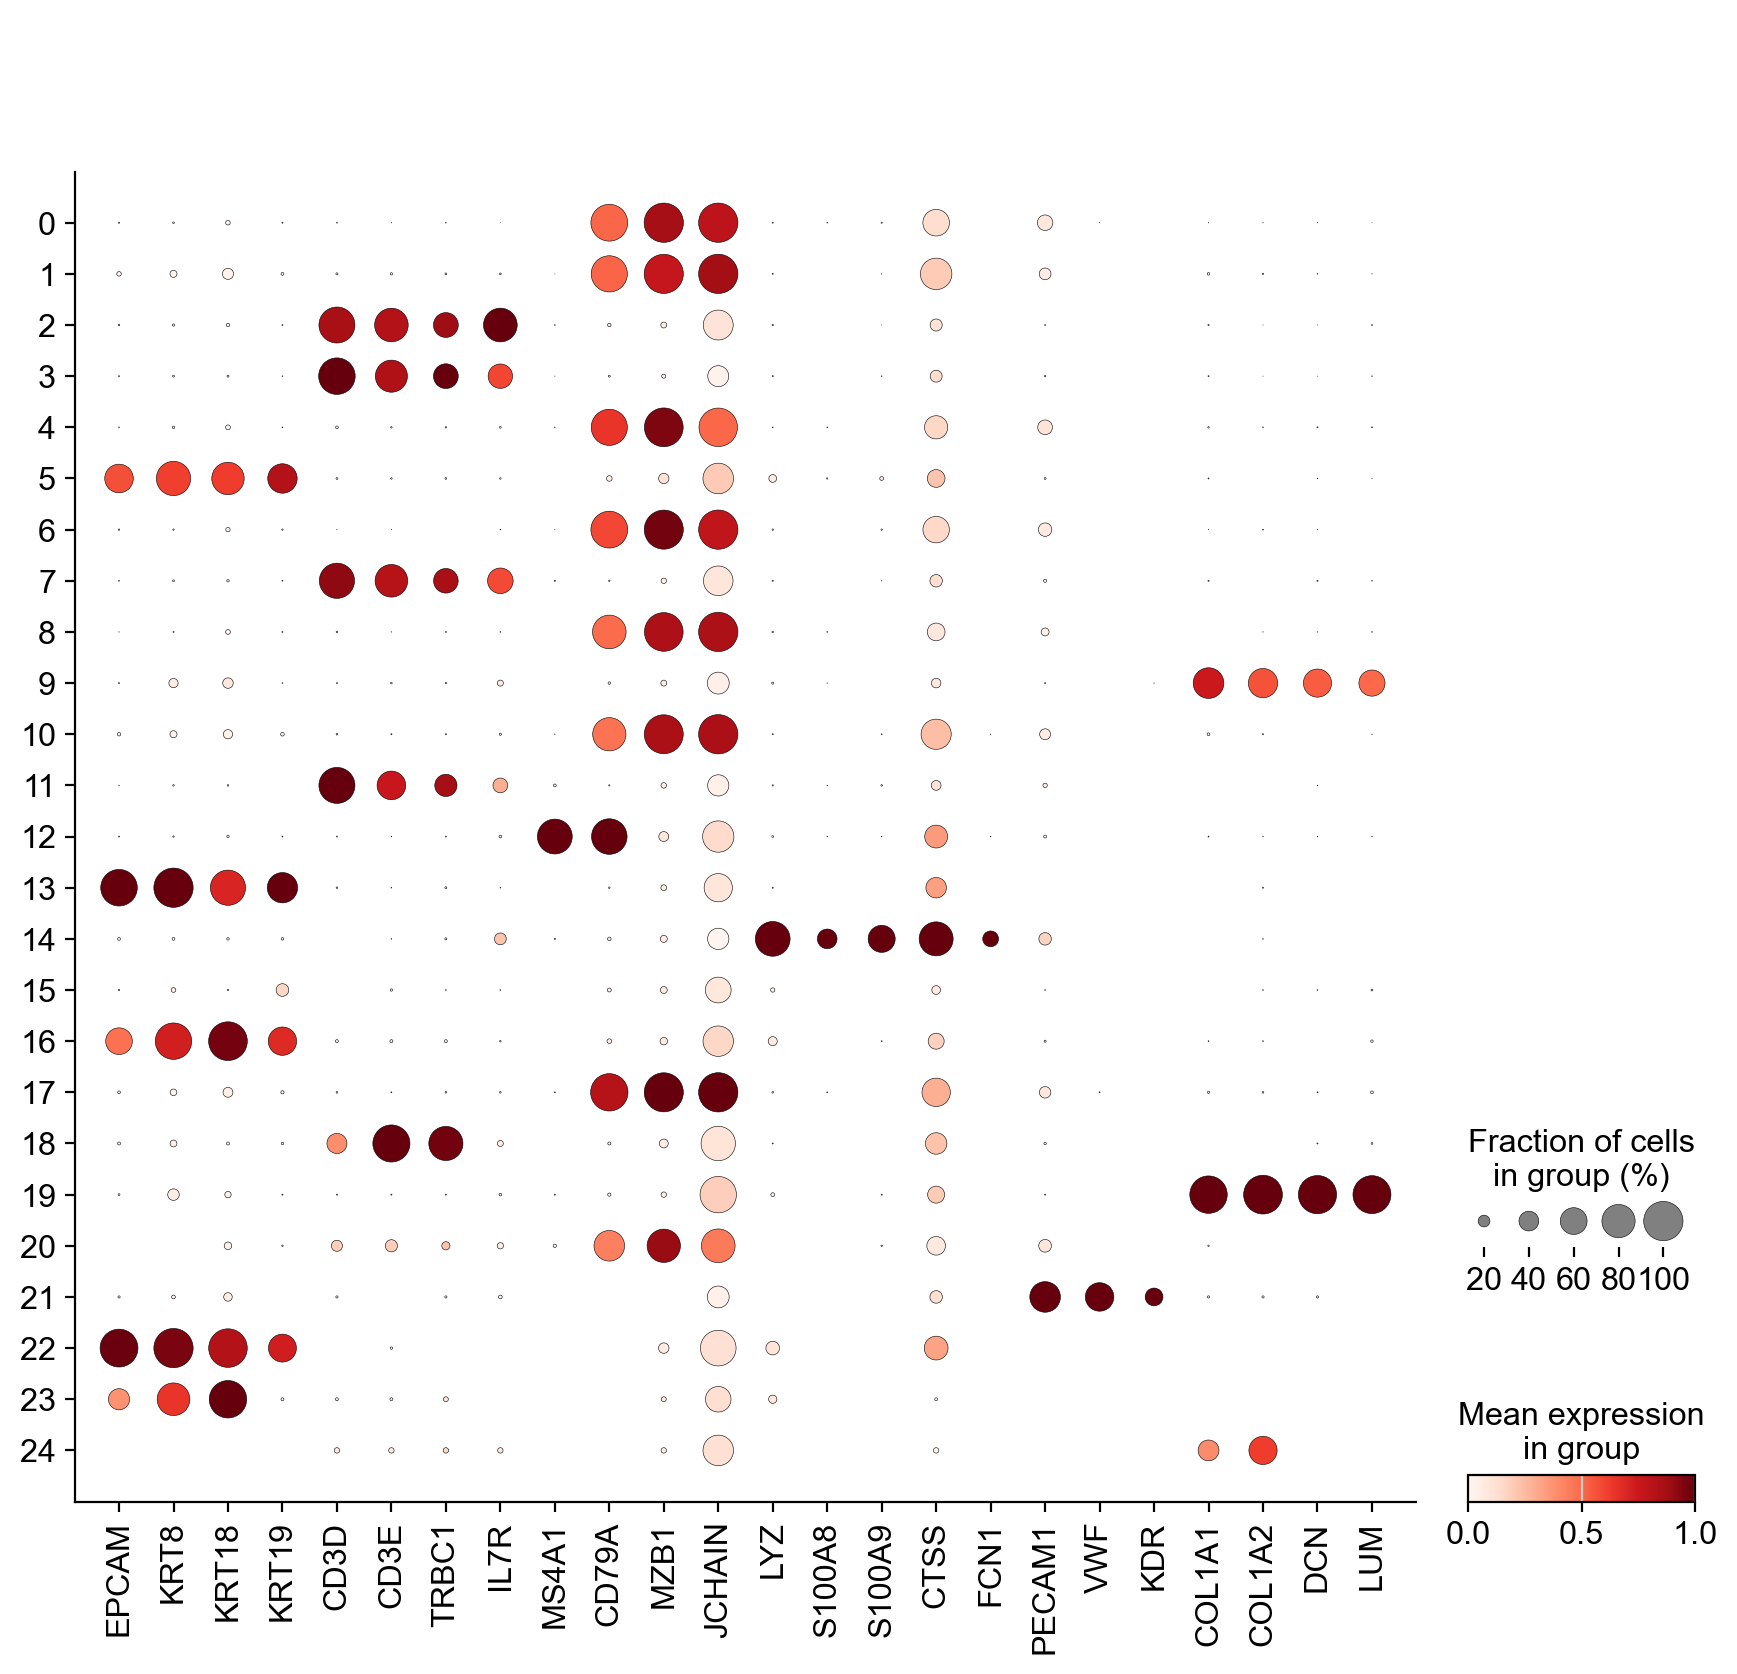

In [48]:
marker_genes = [
    "EPCAM", "KRT8", "KRT18", "KRT19",
    "CD3D", "CD3E", "TRBC1", "IL7R",
    "MS4A1", "CD79A", "MZB1", "JCHAIN",
    "LYZ", "S100A8", "S100A9", "CTSS", "FCN1",
    "PECAM1", "VWF", "KDR",
    "COL1A1", "COL1A2", "DCN", "LUM"
]

present_markers = [g for g in marker_genes if g in adata.raw.var_names]
print("Present marker genes:", present_markers)

if len(present_markers) > 0:
    sc.pl.dotplot(adata, var_names=present_markers, groupby="leiden", standard_scale="var", show=False)
    plt.tight_layout()
    plt.show()
else:
    print("No expected marker genes were found exactly as written. Check gene naming format.")


### Manual annotation step

Edit the mapping below after inspecting the marker dotplot and UMAP.
The values below are placeholders.


In [49]:
cluster_to_celltype = {
    "0": "epithelial",
    "1": "T_cell",
    "2": "myeloid",
    "3": "stromal",
    "4": "B_cell",
    "5": "endothelial",
}

adata.obs["cell_type"] = adata.obs["leiden"].astype(str).map(cluster_to_celltype).fillna("unassigned")
adata.obs["cell_type"].value_counts()


cell_type
unassigned     3794
epithelial      832
T_cell          830
myeloid         672
stromal         617
B_cell          571
endothelial     469
Name: count, dtype: int64

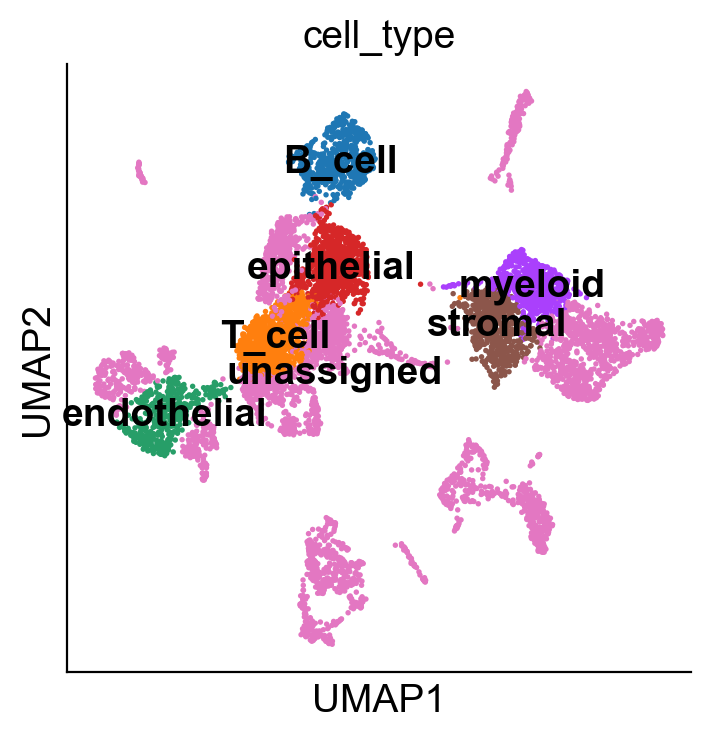

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/sc_real_umap_celltypes.png


In [50]:
sc.pl.umap(adata, color=["cell_type"], legend_loc="on data", show=False)
out = RESULTS_FIGURES / "sc_real_umap_celltypes.png"
plt.savefig(out, bbox_inches="tight")
plt.show()
print("Saved:", out)


## Step 6 — Restrict to UC vs HC


In [51]:
adata_sub = adata[adata.obs["group"].isin(["UC", "HC"])].copy()
print(adata_sub)
print(adata_sub.obs["group"].value_counts())


AnnData object with n_obs × n_vars = 7785 × 3000
    obs: 'sample_id', 'group', 'total_counts', 'n_genes_by_counts', 'batch', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'
group
UC    3954
HC    3831
Name: count, dtype: int64


## Step 7 — Export target expression table


In [52]:
def get_dense_matrix(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)

def build_target_expression_table(adata_sub, target_genes, dataset_name="GSE214695", comparison="UC_vs_HC"):
    genes_present = [g for g in target_genes if g in adata_sub.raw.var_names]
    rows = []

    if len(genes_present) == 0:
        return pd.DataFrame(columns=[
            "gene_symbol", "cell_type", "mean_expr", "pct_expressing", "dataset", "comparison"
        ])

    for cell_type in sorted(adata_sub.obs["cell_type"].dropna().unique()):
        idx = adata_sub.obs["cell_type"] == cell_type
        if idx.sum() == 0:
            continue

        ad = adata_sub[idx].copy()
        mat = pd.DataFrame(
            get_dense_matrix(ad.raw[:, genes_present].X),
            columns=genes_present,
            index=ad.obs_names
        )

        for gene in genes_present:
            vals = pd.to_numeric(mat[gene], errors="coerce")
            rows.append({
                "gene_symbol": gene,
                "cell_type": cell_type,
                "mean_expr": float(vals.mean()),
                "pct_expressing": float((vals > 0).mean()),
                "dataset": dataset_name,
                "comparison": comparison
            })

    return pd.DataFrame(rows)

expr_df = build_target_expression_table(adata_sub, TARGET_GENES)
expr_df.head(20)


,gene_symbol,cell_type,mean_expr,pct_expressing,dataset,comparison
0,NR3C1,B_cell,0.114308,0.187391,GSE214695,UC_vs_HC
1,FKBP5,B_cell,0.012132,0.026270,GSE214695,UC_vs_HC
2,TSC22D3,B_cell,0.720243,0.667250,GSE214695,UC_vs_HC
3,JAK1,B_cell,0.097013,0.161121,GSE214695,UC_vs_HC
4,JAK2,B_cell,0.007149,0.017513,GSE214695,UC_vs_HC
5,JAK3,B_cell,0.022701,0.043783,GSE214695,UC_vs_HC
6,TYK2,B_cell,0.011244,0.024518,GSE214695,UC_vs_HC
7,NR3C1,T_cell,0.115789,0.300000,GSE214695,UC_vs_HC
8,FKBP5,T_cell,0.024583,0.073494,GSE214695,UC_vs_HC
9,TSC22D3,T_cell,1.409068,0.907229,GSE214695,UC_vs_HC


In [53]:
expr_df.to_csv(expr_out_file, sep="\t", index=False)
print("Saved:", expr_out_file)


Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/single_cell/single_cell_target_expression.tsv


## Step 8 — Differential expression for target genes within each cell type


In [54]:
def extract_rank_genes_groups_df(adata_ct, group="UC"):
    try:
        sc.tl.rank_genes_groups(
            adata_ct,
            groupby="group",
            groups=[group],
            reference="HC",
            method="wilcoxon"
        )
        df = sc.get.rank_genes_groups_df(adata_ct, group=group)
        return df
    except Exception as e:
        print(f"DE failed for this subset: {e}")
        return pd.DataFrame()

def build_target_de_table(adata_sub, target_genes, dataset_name="GSE214695", comparison="UC_vs_HC"):
    rows = []

    for cell_type in sorted(adata_sub.obs["cell_type"].dropna().unique()):
        ad_ct = adata_sub[adata_sub.obs["cell_type"] == cell_type].copy()

        if ad_ct.n_obs < 20:
            continue
        if ad_ct.obs["group"].nunique() < 2:
            continue
        if not set(["UC", "HC"]).issubset(set(ad_ct.obs["group"].unique())):
            continue

        de_df = extract_rank_genes_groups_df(ad_ct, group="UC")
        if de_df.empty:
            continue

        de_df["names"] = de_df["names"].astype(str).str.upper()
        subset = de_df[de_df["names"].isin([g.upper() for g in target_genes])].copy()

        if subset.empty:
            continue

        lfc_col = "logfoldchanges" if "logfoldchanges" in subset.columns else None
        padj_col = "pvals_adj" if "pvals_adj" in subset.columns else None

        for _, row in subset.iterrows():
            rows.append({
                "gene_symbol": str(row["names"]).upper(),
                "cell_type": cell_type,
                "log2FC": float(row[lfc_col]) if lfc_col is not None and pd.notna(row[lfc_col]) else np.nan,
                "padj": float(row[padj_col]) if padj_col is not None and pd.notna(row[padj_col]) else np.nan,
                "dataset": dataset_name,
                "comparison": comparison
            })

    return pd.DataFrame(rows)

de_df = build_target_de_table(adata_sub, TARGET_GENES)
de_df.head(20)


ranking genes
    finished (0:00:00)
ranking genes
    finished (0:00:00)
ranking genes
    finished (0:00:00)
ranking genes
    finished (0:00:00)
ranking genes
    finished (0:00:00)
ranking genes
    finished (0:00:00)
ranking genes
    finished (0:00:00)


,gene_symbol,cell_type,log2FC,padj,dataset,comparison
0,JAK2,B_cell,0.216605,1.000000,GSE214695,UC_vs_HC
1,NR3C1,B_cell,0.236048,1.000000,GSE214695,UC_vs_HC
2,FKBP5,B_cell,-0.272742,1.000000,GSE214695,UC_vs_HC
3,JAK3,B_cell,-0.111046,1.000000,GSE214695,UC_vs_HC
4,TYK2,B_cell,-2.027540,1.000000,GSE214695,UC_vs_HC
5,JAK1,B_cell,-0.868265,0.475866,GSE214695,UC_vs_HC
6,TSC22D3,B_cell,-1.465083,0.000015,GSE214695,UC_vs_HC
7,JAK3,T_cell,0.195842,1.000000,GSE214695,UC_vs_HC
8,JAK2,T_cell,-1.190696,1.000000,GSE214695,UC_vs_HC
9,FKBP5,T_cell,-24.701521,1.000000,GSE214695,UC_vs_HC


In [55]:
de_df.to_csv(de_out_file, sep="\t", index=False)
print("Saved:", de_out_file)


Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/single_cell/single_cell_target_differential_expression.tsv


## Step 9 — Target-focused visualizations


In [56]:
present_targets = [g for g in TARGET_GENES if g in adata_sub.raw.var_names]
present_targets


['NR3C1', 'FKBP5', 'TSC22D3', 'JAK1', 'JAK2', 'JAK3', 'TYK2']

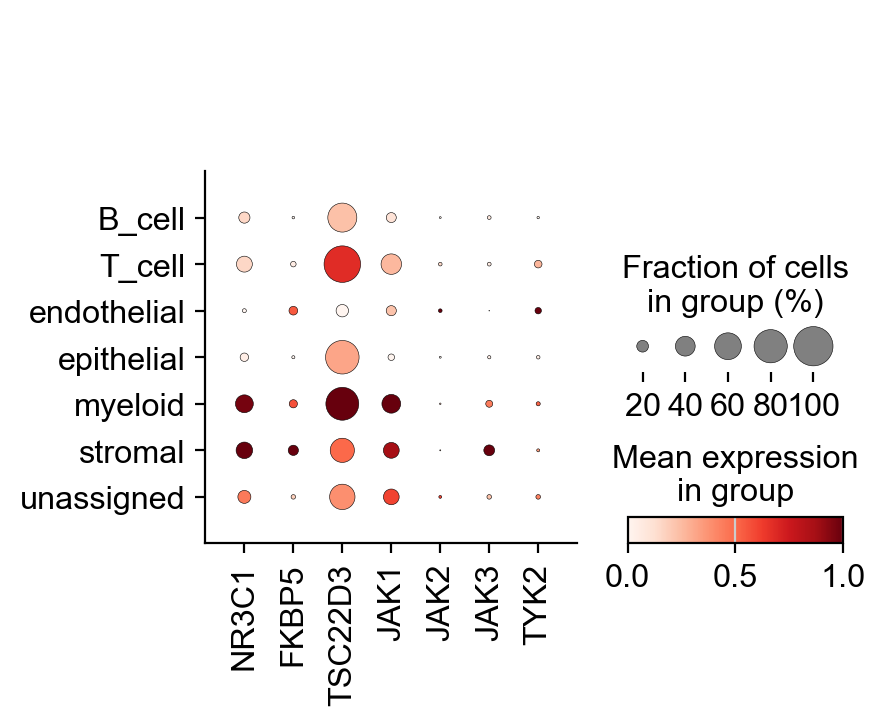

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/sc_real_target_expression_dotplot.png


In [57]:
if len(present_targets) > 0:
    sc.pl.dotplot(
        adata_sub,
        var_names=present_targets,
        groupby="cell_type",
        standard_scale="var",
        show=False
    )
    plt.tight_layout()
    out = RESULTS_FIGURES / "sc_real_target_expression_dotplot.png"
    plt.savefig(out, bbox_inches="tight")
    plt.show()
    print("Saved:", out)
else:
    print("Skipping target dotplot: none of the target genes were found.")


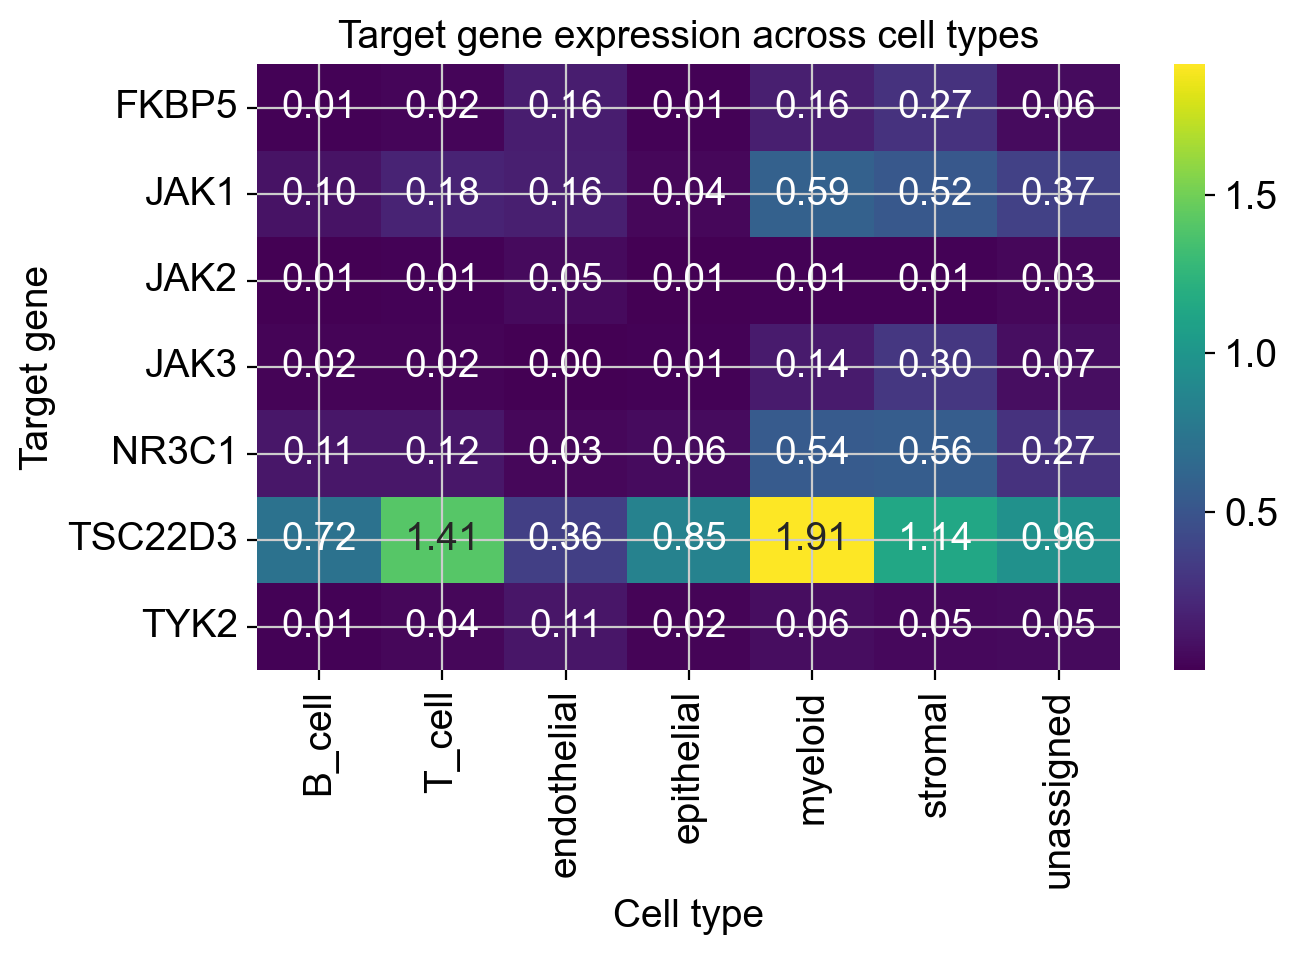

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/sc_real_target_expression_heatmap.png


In [58]:
if not expr_df.empty:
    heat_df = expr_df.pivot_table(
        index="gene_symbol",
        columns="cell_type",
        values="mean_expr",
        aggfunc="mean"
    )
    if heat_df.shape[0] > 0 and heat_df.shape[1] > 0:
        plt.figure(figsize=(7, max(3, 0.5 * heat_df.shape[0] + 1.5)))
        sns.heatmap(heat_df, cmap="viridis", annot=True, fmt=".2f")
        plt.title("Target gene expression across cell types")
        plt.xlabel("Cell type")
        plt.ylabel("Target gene")
        plt.tight_layout()
        out = RESULTS_FIGURES / "sc_real_target_expression_heatmap.png"
        plt.savefig(out, bbox_inches="tight")
        plt.show()
        print("Saved:", out)
    else:
        print("Skipping target expression heatmap: insufficient dimensions.")
else:
    print("Skipping target expression heatmap: expression table is empty.")


In [59]:
adata_out = PROCESSED_SC_DIR / "GSE214695_2HC_2UC_scanpy_processed_corrected.h5ad"
adata_sub.write(adata_out)
print("Saved:", adata_out)


Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/data/processed/single_cell/GSE214695_2HC_2UC_scanpy_processed_corrected.h5ad


## Final next steps

After verifying the output tables, rerun:

1. `05_single_cell_fixed.ipynb`
2. `07_integration.ipynb`
3. `08_final_summary_report.ipynb`
